![](Lesson13_Memory_Management.png)
# 记忆管理 (Memory Management)

- 有效的记忆管理对于智能体保留信息至关重要。智能体需要不同类型的记忆，就像人类一样，以高效操作。
- 本章深入探讨记忆管理，特别关注智能体的短期（即时）和长期（持久）记忆需求。

- 短期记忆（上下文记忆）：
  - 类似于工作记忆，保存当前处理或最近访问的信息。
  - 对于使用大型语言模型（LLM）的智能体，短期记忆主要存在于上下文窗口中。
  - 上下文窗口包含最近的消息、智能体回复、工具使用结果和来自当前交互的反思，这些内容共同通知LLM的后续响应和行为。
  - 上下文窗口容量有限，限制了智能体可以直接访问的近期信息量。
  - 高效的短期记忆管理可能通过总结对话片段或强调关键细节实现。
  - 通过扩展“长上下文”窗口，模型能够在单次交互中保存更多信息。
  - 但上下文是短暂的，交互结束后即丢失，处理代价较高且效率较低。
  - 因此，智能体需要不同的记忆类型以实现持久性、从过去交互中回忆信息并建立知识库。

- 长期记忆（持久记忆）：
  - 充当智能体在多个交互、任务或延长期限中保留信息的仓库，类似于长期知识库。
  - 数据通常存储在智能体即时处理环境之外，如数据库、知识图谱或向量数据库中。
  - 在向量数据库中，信息以数值向量形式存储，便于智能体基于语义相似度（而非关键词匹配）检索数据，即语义搜索。
  - 当智能体需要长期记忆相关信息时，会查询外部存储，获取相关数据并整合到短期上下文以便即时使用，从而将之前的知识与当前交互结合起来。
  
  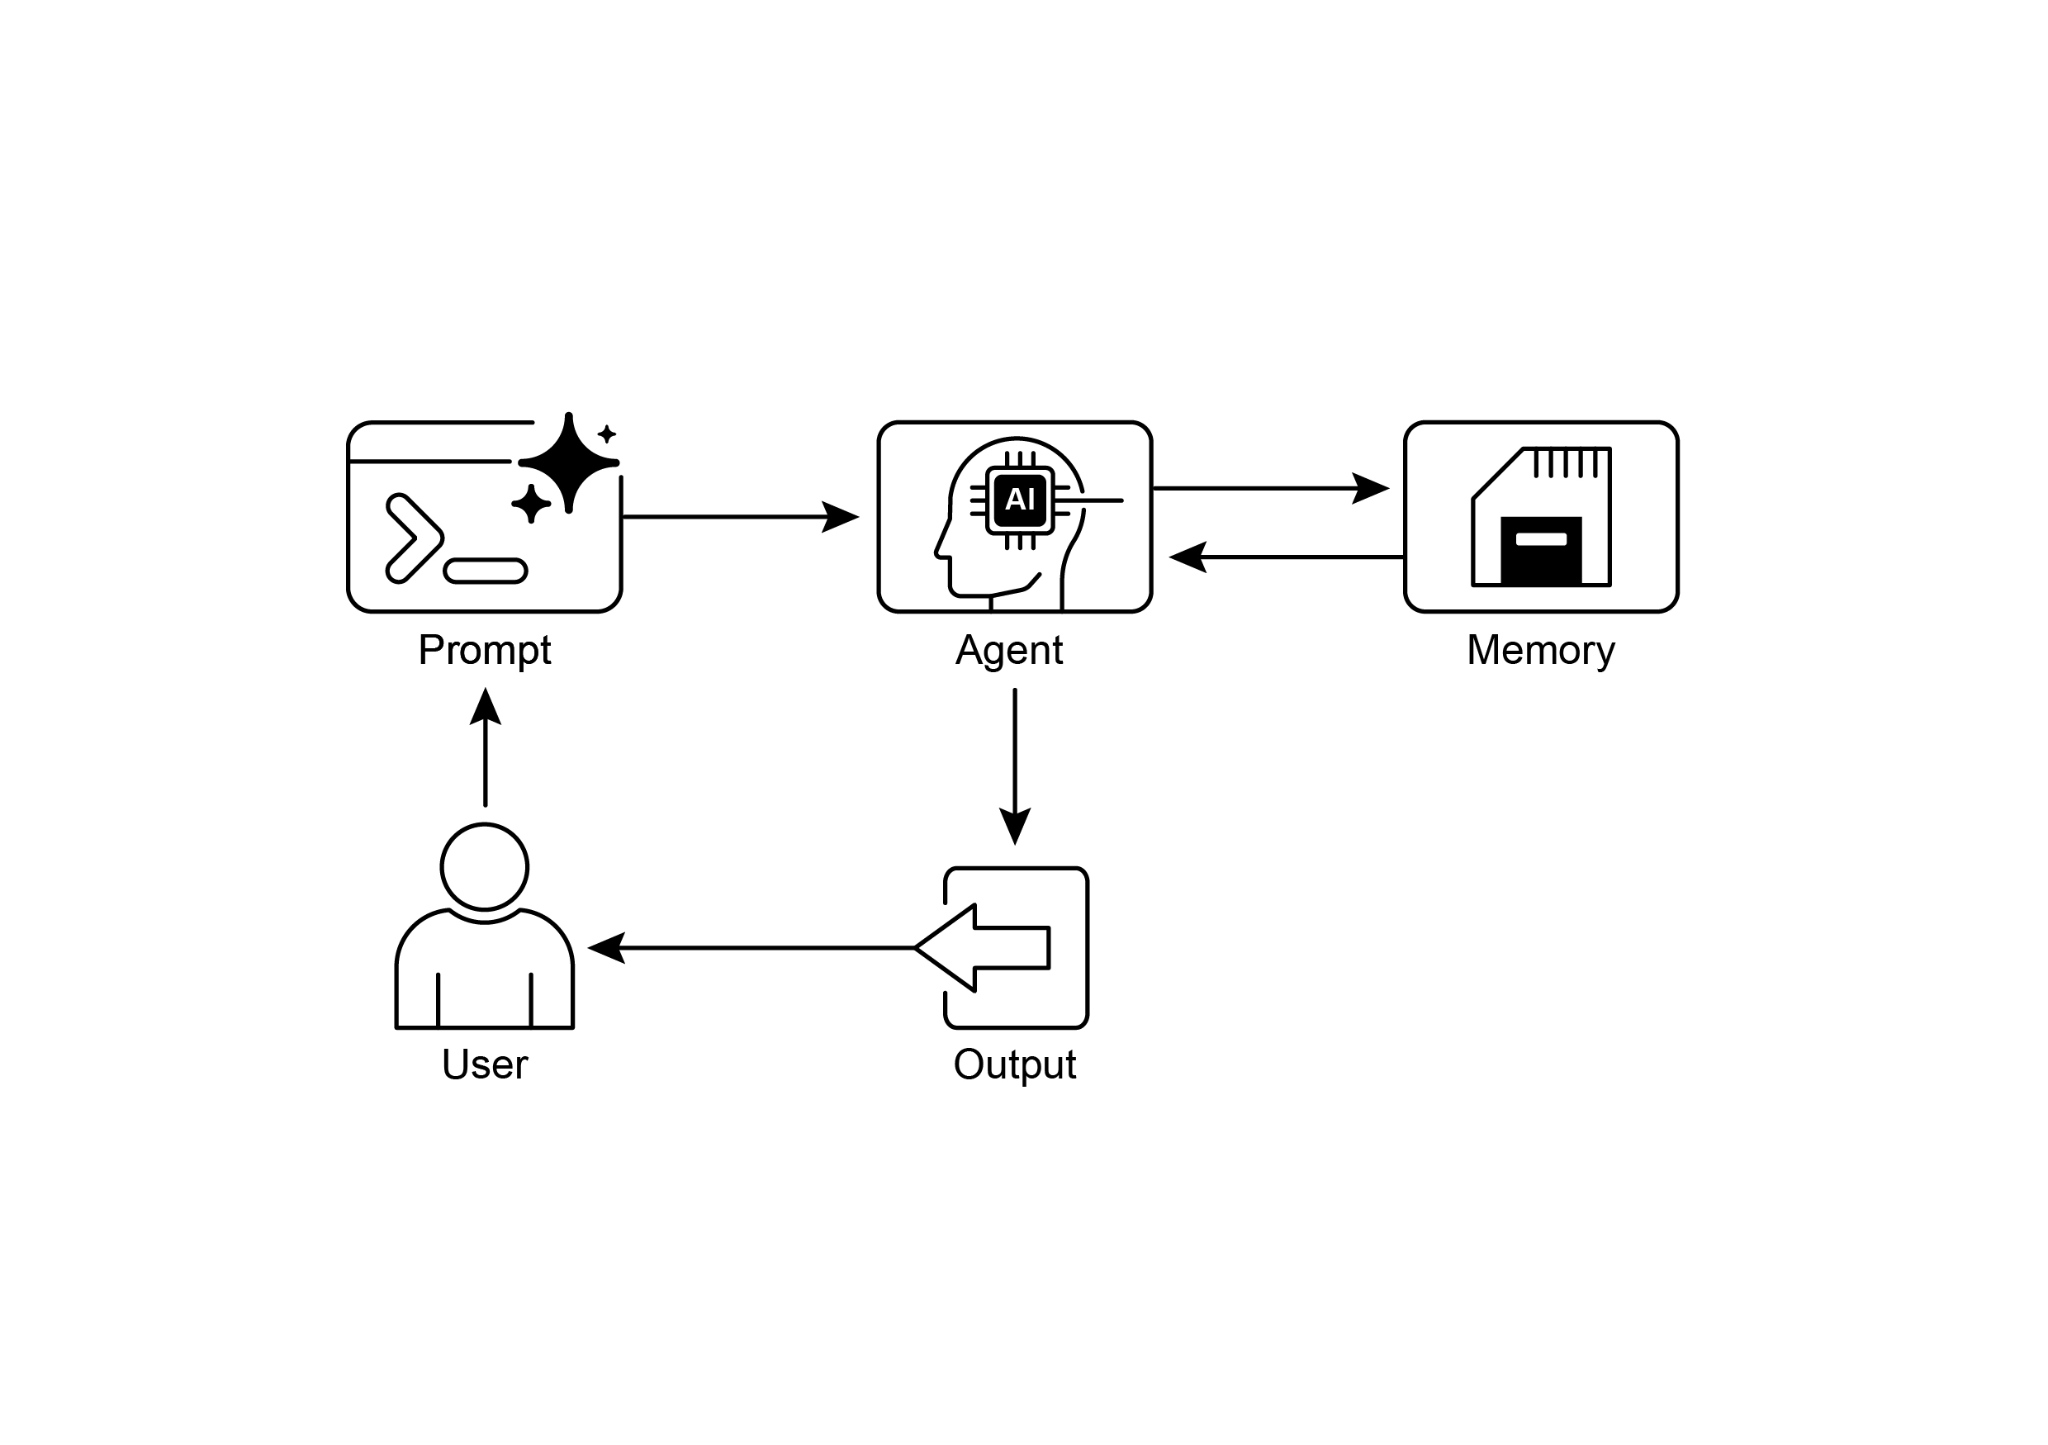

## 实际应用与用例

- **聊天机器人和对话式人工智能**：维持对话流依赖短期记忆。聊天机器人需要记住先前的用户输入以提供连贯的响应。长期记忆使聊天机器人能够回忆用户偏好、过去的问题或讨论，提供个性化和持续的互动。
- **任务导向型代理**：管理多步骤任务的代理需要短期记忆来跟踪先前步骤、当前进展和整体目标。此信息可能存在于任务的上下文或临时存储中。长期记忆对于访问不在即时上下文中的特定用户相关数据至关重要。
- **个性化体验**：提供定制化交互的代理利用长期记忆存储和检索用户偏好、行为历史和个人信息，从而使代理能够调整其响应和建议。
- **学习与改进**：代理通过学习过去的互动来提升性能。成功的策略、错误和新信息被存储在长期记忆中，促进未来的适应。强化学习代理以此方式存储学习到的策略或知识。
- **信息检索（RAG）**：设计用于回答问题的代理访问知识库，其长期记忆通常实现为检索增强生成（RAG）。代理检索相关文档或数据以支持其回答。
- **自主系统**：机器人或自动驾驶汽车需要记忆地图、路线、物体位置和学习到的行为。涉及短期记忆以感知周围环境和长期记忆以掌握一般环境知识。

记忆使代理能够维护历史、学习、个性化交互以及管理复杂的时间依赖问题。

## 实战代码：Google Agent Developer Kit (ADK) 中的记忆管理

- Google Agent Developer Kit (ADK) 提供了一种结构化方法来管理上下文和记忆，包括面向实际应用程序的实用方法。对 ADK 的会话、状态和记忆的牢固理解对于构建需要保留信息的代理至关重要。
- 类似于人类的交互，代理能够回忆以前的交流，以进行连贯和自然的对话。ADK 通过三个核心概念及其关联服务简化了上下文管理。
- 每个与代理的交互都可以被视为一个唯一的对话线程。代理可能需要访问早期交互的信息。ADK 将其结构化如下：
  - **Session（会话）**：单个聊天线程，记录消息和动作（事件）的日志，存储与该特定交互相关的临时数据（状态）。
  - **State（状态，session.state）**：存储于会话内，包含与当前激活的聊天线程相关的信息。
  - **Memory（记忆）**：可搜索的信息存储库，来源于各种过去的聊天或外部资源，作为超越即时对话的数据检索资源。

- ADK 提供了管理构建复杂、状态丰富和上下文感知代理所需的关键组件服务：
  - **SessionService 会话服务**：通过处理会话对象的启动、记录和终止来管理聊天线程。
  - **MemoryService 记忆服务**：负责存储和检索长期知识（记忆）。

- 会话服务和记忆服务均支持各种配置选项：
  - 允许使用基于应用程序需求的不同存储方法。
  - 记忆选项用于测试目的，数据不会在重启后持续存在。
  - 持久存储和可扩展性方面，ADK 还支持数据库和云端服务。



## 会话：跟踪每个聊天

- ADK 中的 Session 对象设计用于跟踪和管理单个聊天线程。
- 与代理对话开始时，SessionService 生成一个 Session 对象，表示该对话：
  - 包含特定会话的唯一识别符（例如 app_name, user_id），
  - 事件对象的时间顺序记录，
  - 跟踪特定临时数据和状态，
  - 以及表示上次更新的时间戳。

- 开发人员通常通过 SessionService 间接与 Session 对象交互。
- SessionService 负责管理生命周期中的各种会话操作，如启动新会话、恢复会话、记录会话活动（包括用户活动）、标识活动会话以及管理会话数据的移除。
- ADK 提供了具有不同存储机制的 SessionService 实现，如记忆中存储和基于持久性的存储。
- 记忆中的 SessionService 适用于测试，但不支持应用重启后的数据持久化。

In [2]:
## 示例：使用 InMemorySessionService
## 这适用于不需要跨应用程序重启的数据持久性的本地开发和测试。
from google.adk.sessions import InMemorySessionService

session_service = InMemorySessionService()

In [ ]:
## 示例：使用 DatabaseSessionService
## 这适用于需要持久存储的生产或开发。
## 您需要配置数据库 URL（例如，用于 SQLite、PostgreSQL 等）。
## 需要：pip install google-adk[sqlalchemy] 和数据库驱动程序（例如，PostgreSQL 的 psycopg2）
from google.adk.sessions import DatabaseSessionService

## 示例使用本地 SQLite 文件：
db_url = "sqlite:///./my_agent_data.db"
session_service = DatabaseSessionService(db_url=db_url)

In [ ]:
## 示例：使用 VertexAiSessionService
## 这适用于 Google Cloud Platform 上的可扩展生产，利用
## Vertex AI 基础设施进行会话管理。
## 需要：pip install google-adk[vertexai] 和 GCP 设置/身份验证
from google.adk.sessions import VertexAiSessionService

PROJECT_ID = "your-gcp-project-id"  # 替换为您的 GCP 项目 ID
LOCATION = "us-central1"  # 替换为您想要的 GCP 位置

## 与此服务一起使用的 app_name 应对应于 Reasoning Engine ID 或名称
REASONING_ENGINE_APP_NAME = "projects/your-gcp-project-id/locations/us-central1/reasoningEngines/your-engine-id"  # 替换为您的 Reasoning Engine 资源名称

session_service = VertexAiSessionService(project=PROJECT_ID, location=LOCATION)

## 使用此服务时，将 REASONING_ENGINE_APP_NAME 传递给服务方法：
## session_service.create_session(app_name=REASONING_ENGINE_APP_NAME, ...)
## session_service.get_session(app_name=REASONING_ENGINE_APP_NAME, ...)
## session_service.append_event(session, event, app_name=REASONING_ENGINE_APP_NAME)
## session_service.delete_session(app_name=REASONING_ENGINE_APP_NAME, ...)

每次消息交换都涉及一个循环过程：接收消息，Runner 使用 SessionService 检索或建立 Session，Agent 使用 Session 的上下文（状态和历史交互）处理消息，Agent 生成响应并可能更新状态，Runner 将其封装为 Event，session_service.append_event 方法记录新事件并更新存储中的状态。然后 Session 等待下一条消息。理想情况下，当交互结束时使用 delete_session 方法终止会话。此过程说明了 SessionService 如何通过管理特定于 Session 的历史和临时数据来维护连续性。

- 在 ADK 中，每个 Session（会话）代表一个聊天线程，包含类似于代理临时工作记忆的状态组件，用于该特定对话的持续时间。
- Session.events 记录整个对话的历史，session.state 负责管理数据的更新并指向当前活动的状态。
- session.state 本质上是一个字典，存储键值对，支持启用代理存储和管理对话所需的关键信息，如用户偏好、任务进度、增量数据集合或影响后续操作的条件标志。
- 结构由键值对组成，值可以是可序列化的 Python 类型（数字、布尔值、列表、字典等），这些类型支持不同数据的持久化和变更。
- 状态组织可通过使用键前缀来定义数据作用域和持久性，未添加前缀的键默认为会话特定。
  - user: 前缀表示跨所有会话关联的用户 ID 数据。
  - app: 前缀表示在应用内共享的所有用户数据。
  - temp: 前缀表示仅对当前处理有效的数据，非持久化存储。
- 代理客户端通过单个 session.state 字典访问状态。SessionService 负责数据检索、合并和持久化，确保更新事件后数据保持最新。
- SessionService_agent.append_event() 确保准确跟踪保存，管理持久服务及状态变更处理。
- 简单方法：使用 output_key（针对代理文本回复）
  - 这是将代理最终文本回复直接插入状态的最简单方式。
  - 只需将 output_key 设为所需的 key，Runner 会自动执行更新操作，保存响应至状态中。

1. **简单方法**：使用 output_key（用于智能体回复）： 如果您只想将智能体的文本响应直接保存到状态中，这是最简单的方法。设置 LlmAgent 时，只需告诉它要使用的 output_key。Runner 看到这一点并在追加事件时自动创建必要的操作以将响应保存到状态。让我们看一个通过 output_key 演示状态更新的代码示例。

In [ ]:
## 从 Google 智能体开发工具包 (ADK) 导入必要的类
from google.adk.agents import LlmAgent
from google.adk.sessions import InMemorySessionService, Session
from google.adk.runners import Runner
from google.genai.types import Content, Part

## 定义带有 output_key 的 LlmAgent。
greeting_agent = LlmAgent(
    name="Greeter",
    model="gemini-2.0-flash",
    instruction="生成一个简短、友好的问候语。",
    output_key="last_greeting"
)

## --- 设置 Runner 和 Session ---
app_name, user_id, session_id = "state_app", "user1", "session1"
session_service = InMemorySessionService()
runner = Runner(
    agent=greeting_agent,
    app_name=app_name,
    session_service=session_service
)

session = session_service.create_session(
    app_name=app_name,
    user_id=user_id,
    session_id=session_id
)

print(f"初始状态：{session.state}")

## --- 运行智能体 ---
user_message = Content(parts=[Part(text="你好")])
print("\n--- 运行 agent ---")
for event in runner.run(
    user_id=user_id,
    session_id=session_id,
    new_message=user_message
):
    if event.is_final_response():
        print("Agent 已响应。")

## --- 检查更新的状态 ---
## 在 runner 完成处理所有事件*之后*正确检查状态。
updated_session = session_service.get_session(app_name, user_id, session_id)
print(f"\nAgent 运行后的状态：{updated_session.state}")

2. **标准方法**：使用 EventActions.state_delta（用于更复杂的更新）： 对于需要执行更复杂操作的时候——例如一次更新多个键、保存不只是文本的内容、针对特定范围（如 user: 或 app:）或进行与智能体文本回复无关的更新——您将手动构建状态更改的字典（state_delta）并将其包含在要追加的 Event 的 EventActions 中。让我们看一个例子：

In [ ]:
import time
from google.adk.tools.tool_context import ToolContext
from google.adk.sessions import InMemorySessionService

## --- 定义推荐的基于工具的方法 ---
def log_user_login(tool_context: ToolContext) -> dict:
    """
    在用户登录事件时更新会话状态。
    此工具封装了与用户登录相关的所有状态更改。
    参数：
        tool_context：由 ADK 自动提供，提供对会话状态的访问。
    返回：
        确认操作成功的字典。
    """
    # 通过提供的上下文直接访问状态。
    state = tool_context.state

    # 获取当前值或默认值，然后更新状态。
    # 这更加清晰并将逻辑共置。
    login_count = state.get("user:login_count", 0) + 1
    state["user:login_count"] = login_count
    state["task_status"] = "active"
    state["user:last_login_ts"] = time.time()
    state["temp:validation_needed"] = True

    print("从 `log_user_login` 工具内部更新了状态。")

    return {
        "status": "success",
        "message": f"已跟踪用户登录。总登录次数：{login_count}。"
    }

## --- 使用演示 ---
## 在真实应用程序中，LLM智能体将调用此工具。
## 在这里，我们模拟直接调用以进行演示。

## 1. 设置
session_service = InMemorySessionService()
app_name, user_id, session_id = "state_app_tool", "user3", "session3"
session = session_service.create_session(
    app_name=app_name,
    user_id=user_id,
    session_id=session_id,
    state={"user:login_count": 0, "task_status": "idle"}
)

print(f"初始状态：{session.state}")

## 2. 模拟工具调用（在真实应用中，ADK Runner 会执行此操作）
## 我们仅为此独立示例手动创建 ToolContext。
from google.adk.tools.tool_context import InvocationContext
mock_context = ToolContext(
    invocation_context=InvocationContext(
        app_name=app_name, user_id=user_id, session_id=session_id,
        session=session, session_service=session_service
    )
)

## 3. 执行工具
log_user_login(mock_context)

## 4. 检查更新的状态
updated_session = session_service.get_session(app_name, user_id, session_id)
print(f"工具执行后的状态：{updated_session.state}")

## 预期输出将显示与"之前"情况相同的状态更改，
## 但代码组织明显更清晰
## 且更健壮。

- 该代码演示了使用基于工具的方法管理应用程序中的用户会话状态。
- 定义了一个名为 `log_user_login` 的函数，该函数作为工具使用。该工具负责在用户登录时更新会话状态。
- 函数接收一个 `ToolContext` 对象，该对象允许访问和修改会话的状态字典。
- 使用该工具时，函数会递增 `user:login_count`，设置任务状态 `task_status` 为 `"active"`，记录用户的最新登录时间 `user:last_login_ts (timestamp)`，并添加一个临时字段 `temp:validation_needed`。
- 代码示例的演示部分展示了如何使用此工具。
- 它设置了一个记忆会话服务，并创建一个带有预定义状态的初始会话。
- 手动创建了一个 `ToolContext` 来模拟在 ADK 运行时执行工具的环境。
- 调用 `log_user_login` 函数模拟用户登录。
- 函数返回后，代码再次检索会话以显示状态已被更新，表明工具使状态更新更干净，且较之前直接修改状态的做法更加有序。
- 直接修改 `session.state` 字典不推荐，因为它绕过了标准事件处理机制，且不会在会话事件历史中记录。
- `SessionService` 选定时，状态不能被持久存储，建议使用推荐的方法通过工具的 `output_key` 参数或事件追加修改状态。
- 在设计状态时应保持简洁，使用基本数据类型，给键使用清晰名称和前缀，避免深度嵌套，并始终通过追加事件过程更新状态。

## 记忆：使用 MemoryService 的长期知识
- 在智能代理系统中，Session组件维护当前聊天历史（事件）和临时数据（状态），仅限于单次对话。
- 为了让代理能够跨多次交互保留信息或访问外部数据，需要长期知识管理，由MemoryService实现。
- 示例代码演示了本地开发和测试时使用InMemoryMemoryService，不需要应用重启即可保持数据。
- Session和State可以作为单次聊天的短期记忆。
- MemoryService管理长期知识，有持久化和可搜索的功能。
- MemoryService可以包含多种会话或外部来源的持久化信息。
- BaseMemoryService接口定义了管理可搜索长期知识的标准。
- 主要功能包括提取会话信息、存储信息、添加会话、检索信息和查询存储的数据。
- ADK提供了多种实现方案，InMemoryMemoryService适合暂存数据和本地测试。
- 生产环境推荐使用VertexAiRagMemoryService，它利用谷歌的云服务和RAG（检索增强生成）技术实现可扩展、持久和语义搜索的知识存储。

In [10]:
## 示例：使用 InMemoryMemoryService
## 这适用于不需要跨应用程序重启数据持久性的本地开发和测试
## 应用停止时记忆内容会丢失
from google.adk.memory import InMemoryMemoryService

memory_service = InMemoryMemoryService()

In [2]:
## 示例：使用 VertexAiRagMemoryService
## 这适用于 GCP 上的可扩展生产，利用
## Vertex AI RAG（检索增强生成）实现持久的、
## 可搜索的记忆。
## 需要：pip install google-adk[vertexai]，GCP
## 设置/身份验证和 Vertex AI RAG Corpus。
from google.adk.memory import VertexAiRagMemoryService

## 您的 Vertex AI RAG Corpus 的资源名称
RAG_CORPUS_RESOURCE_NAME = "projects/your-gcp-project-id/locations/us-central1/ragCorpora/your-corpus-id"  # 替换为您的 Corpus 资源名称

## 检索行为的可选配置
SIMILARITY_TOP_K = 5  # 要检索的顶部结果数
VECTOR_DISTANCE_THRESHOLD = 0.7  # 向量相似度阈值

memory_service = VertexAiRagMemoryService(
    rag_corpus=RAG_CORPUS_RESOURCE_NAME,
    similarity_top_k=SIMILARITY_TOP_K,
    vector_distance_threshold=VECTOR_DISTANCE_THRESHOLD
)

## 使用此服务时，像 add_session_to_memory
## 和 search_memory 这样的方法将与指定的 Vertex AI
## RAG Corpus 交互。

## 实战代码：LangChain 和 LangGraph 中的记忆管理
- 在 LangChain 和 LangGraph 中，记忆是创建智能和自然对话应用的重要组成部分。
- 记忆允许 AI 代理记住来自过去交互、学习反馈并适应偏好的信息。
- LangChain 的记忆功能为存储历史对话提供基础，以丰富当前提示并记录测试交换。
- 记忆对于完成复杂任务非常重要，提高效率和用户满意度。

- **短期记忆**：
  - 具有线程范围，跟踪同一会话中的连续会话。
  - 提供即时上下文，但完整历史可能导致 LLM 的上下文窗口错误或性能降低。
  - LangGraph 管理短期记忆，允许在状态持久化后续线程中恢复。

- **长期记忆**：
  - 存储特定用户或应用的数据，跨会话共享。
  - 以自定义“命名空间”形式保存，可在任何线程中召回。
  - LangGraph 提供存储以保存和召回长期记忆，使代理能够无限期保留记忆。

- LangChain 提供了多种工具，支持从手动控制到链式自动化的会话历史管理。

In [ ]:
from langchain.memory import ChatMessageHistory

## 初始化历史对象
history = ChatMessageHistory()

## 添加用户和 AI 消息
history.add_user_message("我下周要去纽约。")
history.add_ai_message("太好了！这是一个很棒的城市。")

## 访问消息列表
print(history.messages)

- ConversationBufferMemory：用于链条的自动记忆。
- 作用：将记忆直接整合到对话中，是一种常用的选择。
- 功能：保存对话的缓冲区，并将其提供给你的提示。
- 可通过两个关键参数自定义行为：
  - memory_key：指定在提示中存储变量名称的字符串，默认值为“history”。
  - return_messages：控制历史格式的布尔值。
    - False（默认值）：返回单个格式化字符串，适合标准LLMs。
    - True：返回消息对象列表，推荐用于聊天模型。

In [ ]:
from langchain.memory import ConversationBufferMemory

## 初始化记忆
memory = ConversationBufferMemory()

## 保存对话轮次
memory.save_context({"input": "天气怎么样？"}, {"output": "今天是晴天。"})

## 将记忆作为字符串加载
print(memory.load_memory_variables({}))

将此记忆集成到 LLMChain 中允许模型访问对话的历史并提供上下文相关的响应

In [ ]:
from langchain_openai import OpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate
from langchain.memory import ConversationBufferMemory

## 1. 定义 LLM 和提示词
llm = OpenAI(temperature=0)
template = """你是一个有帮助的旅行代理。
之前的对话：
{history}
新问题：{question}
响应："""
prompt = PromptTemplate.from_template(template)

## 2. 配置记忆
## memory_key "history" 与提示词中的变量匹配
memory = ConversationBufferMemory(memory_key="history")

## 3. 构建链
conversation = LLMChain(llm=llm, prompt=prompt, memory=memory)

## 4. 运行对话
response = conversation.predict(question="我想预订航班。")
print(response)
response = conversation.predict(question="顺便说一下，我叫 Sam。")
print(response)
response = conversation.predict(question="我的名字是什么？")
print(response)

为了提高聊天模型的有效性，建议通过设置 return_messages=True 使用消息对象的结构化列表。

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.chains import LLMChain
from langchain.memory import ConversationBufferMemory
from langchain_core.prompts import (
    ChatPromptTemplate,
    MessagesPlaceholder,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
)

## 1. 定义聊天模型和提示词
llm = ChatOpenAI()
prompt = ChatPromptTemplate(
    messages=[
        SystemMessagePromptTemplate.from_template("你是一个友好的助手。"),
        MessagesPlaceholder(variable_name="chat_history"),
        HumanMessagePromptTemplate.from_template("{question}")
    ]
)

## 2. 配置记忆
## return_messages=True 对于聊天模型是必不可少的
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

## 3. 构建链
conversation = LLMChain(llm=llm, prompt=prompt, memory=memory)

## 4. 运行对话
response = conversation.predict(question="嗨，我是 Jane。")
print(response)
response = conversation.predict(question="你记得我的名字吗？")
print(response)

 - 长期记忆类型：长期记忆允许系统在不同对话中保留信息，提供更深层次的上下文和个性化。它可以分为三种类型，类似于人类记忆：

  - 语义记忆：记住事实
    - 涉及保留特定事实和概念，例如用户偏好或领域知识。
    - 用于建立代理的响应基础，带来更个性化和相关的互动。
    - 信息可以作为持续更新的用户“档案”（JSON文档）或独立事实文档进行管理。

  - 情景记忆：记住经历
    - 涉及回忆过去的事件或行动。
    - 对人工智能代理来说，情景记忆常用于记住如何完成任务，通常通过少样本示例提示实现，从成功的交互序列中学习以正确完成任务。

  - 程序记忆：记住规则
    - 是指记住如何执行任务——代理的核心指令和行为，通常包含在系统提示中。
    - 通常是代理为了修改自身提示中的规则以适应和改进而使用的记忆。
    - 有效的技术是“反思”，即代理根据当前指令和最近交互，重新定义自己的指令。

In [ ]:
## 更新 agent 指令的节点
def update_instructions(state: State, store: BaseStore):
    namespace = ("instructions",)
    # 从存储中获取当前指令
    current_instructions = store.search(namespace)[0]

    # 创建提示词要求 LLM 反思对话
    # 并生成新的、改进的指令
    prompt = prompt_template.format(
        instructions=current_instructions.value["instructions"],
        conversation=state["messages"]
    )

    # 从 LLM 获取新指令
    output = llm.invoke(prompt)
    new_instructions = output['new_instructions']

    # 将更新的指令保存回存储
    store.put(("agent_instructions",), "agent_a", {"instructions": new_instructions})

## 使用指令生成响应的节点
def call_model(state: State, store: BaseStore):
    namespace = ("agent_instructions", )
    # 从存储中检索最新指令
    instructions = store.get(namespace, key="agent_a")[0]

    # 使用检索到的指令格式化提示词
    prompt = prompt_template.format(instructions=instructions.value["instructions"])
    # ... 应用程序逻辑继续

LangGraph 将长期记忆存储为存储中的 JSON 文档。每个记忆都在自定义命名空间（如文件夹）和不同的键（如文件名）下组织。这种分层结构便于组织和检索信息。以下代码演示了如何使用 InMemoryStore 放置、获取和搜索记忆。

In [ ]:
from langgraph.store.memory import InMemoryStore

## 真实嵌入函数的占位符
def embed(texts: list[str]) -> list[list[float]]:
    # 在真实应用程序中，使用适当的嵌入模型
    return [[1.0, 2.0] for _ in texts]

## 初始化记忆存储。对于生产，使用数据库支持的存储。
store = InMemoryStore(index={"embed": embed, "dims": 2})

## 为特定用户和应用程序上下文定义命名空间
user_id = "my-user"
application_context = "chitchat"
namespace = (user_id, application_context)

## 1. 将记忆放入存储
store.put(
    namespace,
    "a-memory",  # 此记忆的键
    {
        "rules": [
            "用户喜欢简短、直接的语言",
            "用户只说英语和 python",
        ],
        "my-key": "my-value",
    },
)

## 2. 通过其命名空间和键获取记忆
item = store.get(namespace, "a-memory")
print("检索的项目：", item)

## 3. 在命名空间内搜索记忆，按内容过滤
## 并按与查询的向量相似度排序。
items = store.search(
    namespace,
    filter={"my-key": "my-value"},
    query="语言偏好"
)
print("搜索结果：", items)

## Vertex Memory Bank（记忆库）
- 顶点记忆库（Vertex Memory Bank）是Vertex AI Agent Engine中的一个托管服务，提供持久且长期的记忆。
- 该服务使用Gemini模型异步分析对话历史，以提取关键信息和用户偏好。
- 信息被持久化存储，按照定义的空间进行组织，比如用户ID，并智能更新以整合新数据和解决矛盾。
- 在启动新会话时，代理会检索相关记忆，通过调用资料或相似搜索使用嵌入来完成。
- 该过程允许代理在整个会话过程中持续访问记忆内容，并根据回忆信息个性化响应。
- 代理的运行者与VertexAiMemoryBankService交互，该服务负责自动存储代理生成的记忆内容。
- 每条记忆都被标记有唯一的USER_ID和APP_NAME，以确保记忆的关联性。

In [ ]:
from google.adk.memory import VertexAiMemoryBankService

agent_engine_id = agent_engine.api_resource.name.split("/")[-1]
memory_service = VertexAiMemoryBankService(
    project="PROJECT_ID",
    location="LOCATION",
    agent_engine_id=agent_engine_id
)

session = await session_service.get_session(
    app_name=app_name,
    user_id="USER_ID",
    session_id=session.id
)

await memory_service.add_session_to_memory(session)

# 实战代码: Datasurfer

In [4]:
import datasurfer as ds 
agent = ds.Agent()
agent.receive("顺便说一下，我叫 Sam。")
agent.receive("我的名字是什么？")

agent.history

[{'output': [{'type': 'message',
    'role': 'user',
    'content': [{'text': '顺便说一下，我叫 Sam。', 'type': 'output_text'}]}],
  'agent_name': 'User'},
 {'output': [{'type': 'message',
    'role': 'user',
    'content': [{'text': '我的名字是什么？', 'type': 'output_text'}]}],
  'agent_name': 'User'}]

In [5]:
response = agent.reply();

Assistant:

    Reasoning:
    用户告诉我他的名字叫 Sam，然后问我的名字是什么。这是一个简单的对话问题，不需要使用任何工具或技能指令。我应该直接回答这个问题。

    根据上下文，我是 AI 助手，但在这个特定的对话中，我没有被赋予具体的名字。不过，从之前的系统提示来看，我似乎是一个代码审查者（code-reviewer）角色，但这只是我的功能之一。

    对于这个问题，我应该友好地回应：
    1. 确认我知道用户叫 Sam
    2. 说明我自己的身份/名字

    由于没有特定的技能指令适用于这个简单的自我介绍问题，我将直接回答。

    你好，Sam！很高兴认识你。

    至于我，我是一个 AI 助手，在这个对话中我没有特定的个人名字。你可以叫我助手、AI，或者任何你觉得舒服的名字 😊

    有什么我可以帮你的吗？

--------------------------------------------------------------------------------------------------------



In [ ]:
# 将记忆持久化到本地文件
agent.save_memory('agent_memory.json')

Agent(name=Assistant, role=Assistant, model=None, tools=10, skills=13, mcp_servers=None, subagents=0)

In [ ]:
# 重置agent，调取记忆
agent.reset().load_memory('agent_memory.json')
agent.resp('我叫什么？');

Assistant:

    Reasoning:
    用户问"我叫什么？"，这是一个简单的问题。根据之前的对话历史，用户告诉我他的名字叫 Sam。所以答案应该是 Sam。

    这个问题不需要使用任何工具，直接回答即可。

    你叫 **Sam**。😊

--------------------------------------------------------------------------------------------------------



## Hermes 以记忆学习与自进化闭环为核心的 AI Agent 架构剖析
Hermes 的核心不是更复杂的工具调用，而是“运行时闭环自进化”：在使用中记忆事实、抽象为可复用技能、自动修复与索引，并通过上下文压缩保持长期有效性——从而实现“越用越好”的 Agent。

关键要点
- 项目定位：超越工具调用封装器，强调持久记忆与自我进化能力。
- 四层能力是递进关系，每层都为上一层的不足提供补丁（记住 → 复用 → 进化 → 持久）。
- 记忆采用双文件（MEMORY.md / USER.md）、字符上限、冻结快照与并发安全机制，优先保存可防止用户重复纠正的信息。
- session_search 支持零成本浏览与基于 FTS5 的关键词居中截取 + 并行摘要，解决大量对话细节检索问题。
- Skills（程序性记忆）以人可读的 SKILL.md 保存，按需索引与加载，容量大且按条件注入以节省 token。
- 自进化闭环由五步组成：引导(SKILLS_GUIDANCE) → 创建(skill_manage.create) → 自动索引 → 执行(skill_view) → 实时修复(skill_manage.patch)，整个流程无需人工干预。
- ContextCompressor 分层压缩对话（保护头尾、摘要中间、迭代更新），确保长会话中进化链不被上下文窗口溢出打断。
- 安全与工程实践：注入检测（多达 12 种模式）、文件锁与原子写入、技能创建/修补的回滚机制，降低自写入带来的风险。

四层能力速览
- 第一层（能记住）：MEMORY.md / USER.md + 冻结快照 + 并发写入协议，解决跨会话事实与偏好保留。
- 第二层（能复用）：SKILL.md 把过程/方法编码为可执行步骤，按需加载减少 prompt 体积。
- 第三层（能进化）：提示词引导下的闭环让 Agent 主动创建与修补技能，实现运行时自我改进。
- 第四层（能持久）：ContextCompressor 在长期会话里保护历史信息，保证闭环操作的连续性。

| 文件        | 字符上限     | 内容                   | 类比           |
| --------- | -------- | -------------------- | ------------ |
| MEMORY.md | 2,200 字符 | 环境事实、工具怪癖、项目约定、学到的经验 | Agent 的工作笔记  |
| USER.md   | 1,375 字符 | 用户偏好、沟通风格、期望、工作习惯    | Agent 对用户的画像 |

工程亮点（可直接借鉴）
- 冻结快照（read/freeze vs. write-through）在性能与一致性间的务实权衡。
- 把程序性知识用自然语言的 SKILL.md 编码，便于任何 LLM 继承与审阅。
- 三重/四重安全检查（扫描、信任目录、回滚）在 Agent 自主写入场景中至关重要。
- 以“防止用户重复纠正”为记忆优先级，保证记忆空间的高效利用。



| 启示          | Hermes 的做法         | 建议                   |
| ----------- | ------------------ | -------------------- |
| 记忆需要工程化     | 冻结快照 + 安全扫描 + 字符限制 | 不要简单地把记忆塞进 prompt    |
| 进化不需要微调     | 自然语言技能文件 + 反馈闭环    | 在考虑 RLHF 前先试运行时学习    |
| "最好的记忆是防纠正" | 优先记忆用户偏好和常见修正      | 引导 Agent 记住减少用户干预的信息 |
| 安全是记忆的前提    | 所有写入前经过注入检测        | Agent 自写入的持久化内容都要扫描  |
| 渐进式知识加载     | 三层技能披露 + 条件激活      | 用户只需看到相关知识           |



- Hermes 的记忆由“内置记忆（两个核心文件）+ 可选外部 Memory Provider + 运行时上下文快照”组成；记忆写入是 Agent 策展（Agent-curated）并通过周期性 nudge 固化，而非每轮实时写入。

核心架构
- 内置记忆（始终激活）：主要由 ~/.hermes/memories/ 下的 MEMORY.md（工作笔记、环境事实，系统阈值 ~2,200 字符）和 USER.md（用户画像、偏好，系统阈值 ~1,375 字符）构成。每次会话启动时以“冻结快照”注入上下文。  
- 外部 Memory Provider（可选叠加）：例如 Mem0、Holographic、Supermemory 等，按 provider 行为在合适时机提取/同步长期记忆。  
- 运行时上下文：会话内新写入的内容通常不会立即改变当前会话的冻结头部，需通过后续反思/会话或 nudge 固化。

为何“记不住”（Agent-curated 原理）
- 设计目标：节省 token / 提高推理速度（保持前缀稳定以利用 KV Cache）并避免记忆污染（不保留中间试错碎念）。  
- 结果：Agent 只把“被判定为重要”的信息写入长期记忆，且写入往往由 nudge_interval 等节奏控制触发，而非每轮即时写入。

什么更容易被记住（触发条件）
- 明确偏好（例如“以后所有脚本用 Python 3.11”）  
- 环境事实或配置（例如“这台机器装了 X”）  
- 用户纠正 Agent 的做法或重要任务里程碑  
- 用户明确要求“请把这件事写入长期记忆”

关键配置与调优
- nudge_interval（~5、10、15 等）：数值越小越频繁触发记忆反思与写入，但 token 成本更高。小模型/小上下文可用 3~5，标准模型 5~10，大上下文模型可 10~15。修改路径：~/.hermes/config.yaml 中 memory.nudge_interval。  
- 外部 provider 配置按 provider 文档（示例：hermes config set memory.provider mem0，需设 API Key）。

核心文件与职责
- MEMORY.md：Agent 的工作笔记、可被整理压缩（放高频事实与流程）  
- USER.md：用户偏好/沟通风格（保持精炼）  
- SOUL.md：Agent 人格/固定规则（适合由用户写，放不可被自动重写的约束）  
- AGENTS.md：项目级行为规范（放在项目根）

实战技巧（快速可用）
- 想让 Hermes 记住：直接下指令“请把 X 写入长期记忆”。  
- 测试写入：进行多轮对话（≥5 轮）、然后查看 ~/.hermes/memories/MEMORY.md。  
- 跨会话长任务：手动插入 Checkpoint（“请把当前进度写入记忆”）或使用 TASK_STATUS.md 作为任务状态文件。  
- 内存接近上限：手动整理（合并、删除过时条目）或让 Agent 执行“整理记忆”命令。  
- 把重复流程变成 Skill：当 MEMORY.md 中多次记录某流程时，应把它变成 Skill（存于 skills/），以降低重复推理并提高复用性。

外部 Provider 推荐（速览）
- Mem0：省心、自动化高（适合快速接入）  
- Holographic：偏本地、隐私优先（适合不愿上云的场景）

常见问题与快速解法
- 告诉了 Agent 但下次不记得：会话太短或 Agent 认为信息不重要。解决：明确指令写入、增加交互轮次或调整 nudge_interval。  
- 要保留固定规则不要被覆盖：把这类内容放入 SOUL.md（而非 MEMORY.md）。

简短操作清单
- 明确写入：在会话中说“请把 X 写入长期记忆”。  
- 调试记忆：hermes memory status（查看 provider 状态）／cat ~/.hermes/memories/MEMORY.md（查看内容）。  
- 调整频率：编辑 ~/.hermes/config.yaml 的 memory.nudge_interval。  
- 长任务保活：在关键点写入 Checkpoint 或维护 TASK_STATUS.md。


## 关键要点总结

- 记忆对于代理跟踪事物、学习和个性化交互至关重要。
- 对话式 AI 依赖于短期记忆用于即时上下文，并依赖长期记忆来持久化跨多次会话的知识。
- 短期记忆（即时内容）是临时的，通常受限于语言模型（LLM）的上下文窗口或框架传递的上下文。
- 长期记忆（持久内容）存储在跨不同聊天之外的地方，使用向量数据库等工具存储并通过搜索访问。
- 框架如 ADK 有特定部分包括 Session（聊天线程）、State（临时状态）和 MemoryService（可检索的长期记忆）来管理记忆。
- ADK 的 SessionService 处理整个聊天会话的生命周期，包括历史（事件）和临时数据（状态）。
- ADK 的 session.state 是临时聊天数据的字典。前缀（user:, app:, temp:）告诉你数据所属及是否保留。
- 在 ADK 中，你应通过 EventActions.state_delta 或 output_key 更新状态，而不是直接更改状态字典。
- ADK 的 MemoryService 负责将信息存入长期存储，并协助代理搜索，通常使用工具。
- LangChain 提供如 ConversationBufferMemory 的实用工具，可以自动注入单个会话历史到提示中，帮助代理快速获得上下文。
- LangGraph 支持先进的长期记忆，能通过保存和检索语义事实、情节经验或可更新的规则，跨不同会话管理记忆。
- Memory Bank 是一个托管服务，提供持久的长期记忆，通过自动提取、存储和检索用户特定信息，实现个性化、持续的跨会话对话，结合了 Google 的 ADK、LangGraph 和 CrewAI 等技术。

